<a href="https://colab.research.google.com/github/newboo-me/Credit-Risk-Prediction-XAI/blob/main/Credit_Risk_Dataset_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')

Mounted at /content/drive


missing
data clearning

In [ ]:
import numpy as np
import pandas as pd

# โหลดข้อมูล
df = pd.read_csv("/content/drive/MyDrive/credit_risk_dataset.csv", low_memory=False)

#  ตรวจสอบ Missing Values ปกติ (พร้อมดูสัดส่วน %)
print("=== 1. Missing Values (NaN) ===")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame(
    {"Missing_Count": missing, "Percentage (%)": missing_percent}
)
print(missing_df[missing_df["Missing_Count"] > 0])

#  ตรวจสอบค่าแฝงใน Categorical Columns
print("\n=== 2. ตรวจสอบค่าแปลกปลอมในคอลัมน์ข้อความ ===")
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    unique_vals = df[col].unique()
    print(f"{col}: {unique_vals}")

#  ตรวจสอบค่าทางสถิติผิดปกติ (Logical Anomalies)
print("\n=== 3. ตรวจสอบค่าสถิติผิดปกติ (Outliers ที่เป็นไปไม่ได้) ===")
print("อายุสูงสุด (Max Age):", df["person_age"].max())
print("อายุงานสูงสุด (Max Emp Length):", df["person_emp_length"].max())
print(
    "จำนวนคนที่อายุ > 100 ปี:", len(df[df["person_age"] > 100]), "แถว"
)
print(
    "จำนวนคนที่อายุงาน > 60 ปี:",
    len(df[df["person_emp_length"] > 60]),
    "แถว",
)

=== 1. Missing Values (NaN) ===
                   Missing_Count  Percentage (%)
person_emp_length            895        2.747000
loan_int_rate               3116        9.563856

=== 2. ตรวจสอบค่าแปลกปลอมในคอลัมน์ข้อความ ===
person_home_ownership: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
loan_grade: ['D' 'B' 'C' 'A' 'E' 'F' 'G']
cb_person_default_on_file: ['Y' 'N']

=== 3. ตรวจสอบค่าสถิติผิดปกติ (Outliers ที่เป็นไปไม่ได้) ===
อายุสูงสุด (Max Age): 144
อายุงานสูงสุด (Max Emp Length): 123.0
จำนวนคนที่อายุ > 100 ปี: 5 แถว
จำนวนคนที่อายุงาน > 60 ปี: 2 แถว


In [ ]:
#  จัดการตัด Outliers ทางตรรกะทิ้ง (ตัดคนอายุ > 100 ปี และ อายุงาน > 60 ปี)
df_cleaned = df[(df["person_age"] <= 100) & (df["person_emp_length"] <= 60)].copy()

# หมายเหตุ: กรณีคนที่มีค่าว่าง (NaN) ใน person_emp_length จะยังคงถูกเก็บไว้ด้วยการกรองร่วม
df_cleaned = df[
    (df["person_age"] <= 100)#ตั้งเงื่อนไขเลือกเฉพาะคนที่อายุไม่เกิน 100 ปี (ตัดอายุ 144 ปีที่เป็นไปไม่ได้ทิ้ง)
    & ((df["person_emp_length"] <= 60) | (df["person_emp_length"].isnull()))#งเงื่อนไขเลือกคนที่มีอายุงานไม่เกิน 60 ปี หรือ (|) คนที่ช่องอายุงานยังเป็นค่าว่าง (NaN) เพราะเรายังต้องเก็บคนที่ข้อมูลว่างไว้ไปจัดการเติมค่าในขั้นตอนถัดไป ไม่เผลอตัดทิ้งไปก่อน
].copy()

#  เติม Missing Values ด้วยค่า Median (มัธยฐาน)
emp_median = df_cleaned["person_emp_length"].median()#ดึงคอลัมน์อายุงาน (person_emp_length) มาหาค่ากึ่งกลางหรือค่ามัธยฐานด้วยคำสั่ง .median() แล้วเก็บค่าตัวเลขไว้ในตัวแปร emp_median (ใช้มัธยฐานแทนค่าเฉลี่ยเพื่อไม่ให้โดนค่าสุดโต่งดึงความแม่นยำ)
int_rate_median = df_cleaned["loan_int_rate"].median()#ดึงคอลัมน์อัตราดอกเบี้ย (loan_int_rate) มาหาค่ามัธยฐานด้วยคำสั่ง .median() แล้วเก็บไว้ในตัวแปร int_rate_median

df_cleaned["person_emp_length"] = df_cleaned["person_emp_length"].fillna(emp_median)#คำสั่ง .fillna() จะค้นหาจุดที่เป็นค่าว่าง (NaN) ในคอลัมน์ person_emp_length ทั้งหมด แล้วแทนที่ด้วยค่ามัธยฐานที่คำนวณไว้ จากนั้นบันทึกทับลงคอลัมน์เดิม
df_cleaned["loan_int_rate"] = df_cleaned["loan_int_rate"].fillna(int_rate_median)#นำค่าว่างในคอลัมน์อัตราดอกเบี้ย loan_int_rate มาแทนที่ด้วยค่ามัธยฐาน int_rate_median แล้วบันทึกทับลงคอลัมน์เดิม

#  ตรวจสอบผลลัพธ์หลังทำความสะอาด
print("--- ตรวจสอบ Missing Values หลังทำความสะอาด ---")
print(df_cleaned[["person_emp_length", "loan_int_rate"]].isnull().sum())

print("\n--- ตรวจสอบค่าสถิติสูงสุดหลังกำจัด Outlier ---")
print("Max Age:", df_cleaned["person_age"].max())
print("Max Emp Length:", df_cleaned["person_emp_length"].max())
print(f"จำนวนข้อมูลเดิม: {len(df)} แถว | จำนวนข้อมูลหลังคลีน: {len(df_cleaned)} แถว")

--- ตรวจสอบ Missing Values หลังทำความสะอาด ---
person_emp_length    0
loan_int_rate        0
dtype: int64

--- ตรวจสอบค่าสถิติสูงสุดหลังกำจัด Outlier ---
Max Age: 94
Max Emp Length: 41.0
จำนวนข้อมูลเดิม: 32581 แถว | จำนวนข้อมูลหลังคลีน: 32574 แถว


=== 1. Chi-Square Test: Home Ownership vs Loan Status ===
Chi-Square Statistic: 1907.3970
P-value: 0.0000e+00
-> สรุป: ปฏิเสธ H0 (สถานะที่อยู่อาศัย 'มีความสัมพันธ์' กับการเบี้ยวหนี้อย่างมีนัยสำคัญ)

=== 2. Independent T-Test: Interest Rate by Loan Status ===
T-Statistic: -56.8925
P-value: 0.0000e+00
ดอกเบี้ยเฉลี่ย กลุ่มปกติ: 10.49% | กลุ่มเบี้ยวหนี้: 12.87%
-> สรุป: ปฏิเสธ H0 (อัตราดอกเบี้ยของสองกลุ่ม 'แตกต่างกัน' อย่างมีนัยสำคัญ)



/tmp/ipykernel_3812/2838499377.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='loan_status', y='loan_int_rate', palette='Set2')#วาด Boxplot (กราฟกล่อง) แกน X คือกลุ่มเบี้ยวหนี้ แกน Y คืออัตราดอกเบี้ย (กราฟนี้จะบอกได้ชัดเจนมากว่ากลุ่มที่ 1 มีกล่องที่ขยับลอยสูงขึ้นไปกว่ากลุ่ม 0 จริงไหม)


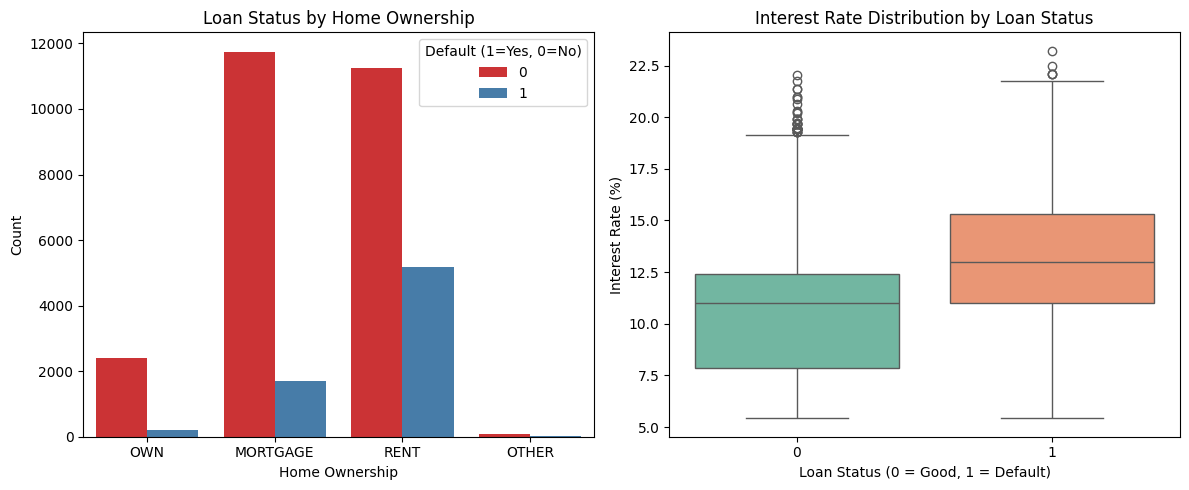

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind

# การทดสอบ Chi-Square (Categorical vs Categorical) ใช้เช็กว่า "ข้อมูลที่เป็นกลุ่ม/ข้อความ 2 เรื่อง มันเกี่ยวข้องกันจริงๆ หรือแค่บังเอิญ?"
# สมมติฐาน (H0): สถานะที่อยู่อาศัย ไม่มีผลต่อการผิดนัดชำระหนี้
# สมมติฐาน (H1): สถานะที่อยู่อาศัย มีผลต่อการผิดนัดชำระหนี้

print("=== 1. Chi-Square Test: Home Ownership vs Loan Status ===")

# สร้างตาราง Crosstab
contingency_table = pd.crosstab(df_cleaned['person_home_ownership'], df_cleaned['loan_status'])
chi2, p_val_chi2, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")#.4f คือทศนิยม 4 ตำแหน่ง
print(f"P-value: {p_val_chi2:.4e}")#ส่วน .4e คือให้พิมพ์ P-value ในรูปแบบสัญกรณ์วิทยาศาสตร์ เผื่อค่ามันเล็กมากแบบ $10^{-5}$)
if p_val_chi2 < 0.05:
    print("-> สรุป: ปฏิเสธ H0 (สถานะที่อยู่อาศัย 'มีความสัมพันธ์' กับการเบี้ยวหนี้อย่างมีนัยสำคัญ)\n")
else:
    print("-> สรุป: ยอมรับ H0 (ไม่มีความสัมพันธ์กัน)\n")  #ให้คอมพิวเตอร์ช่วยสรุปผลเลยว่า ถ้า P-value ต่ำกว่า 0.05 ให้พิมพ์บอกว่า "ปฏิเสธ H0 (มีความสัมพันธ์กัน)" แต่ถ้าไม่ต่ำกว่า ก็พิมพ์ว่า "ยอมรับ H0 (ไม่เกี่ยวข้องกัน)"


#  การทดสอบ Independent T-Test (Continuous vs Categorical)  ใช้เปรียบเทียบ "ค่าเฉลี่ยที่เป็นตัวเลข ของคน 2 กลุ่ม ว่ามันต่างกันแบบมีนัยสำคัญไหม?"
# สมมติฐาน (H0): ดอกเบี้ยเฉลี่ยของกลุ่มที่จ่ายปกติ และกลุ่มที่เบี้ยวหนี้ ไม่ต่างกัน
# สมมติฐาน (H1): ดอกเบี้ยเฉลี่ยของสองกลุ่ม แตกต่างกัน

print("=== 2. Independent T-Test: Interest Rate by Loan Status ===")

# แยกกลุ่มข้อมูลดอกเบี้ย
rate_good = df_cleaned[df_cleaned['loan_status'] == 0]['loan_int_rate']
rate_bad = df_cleaned[df_cleaned['loan_status'] == 1]['loan_int_rate']

# ทำ T-Test (ใช้ equal_var=False หรือ Welch's t-test เพราะความแปรปรวนอาจไม่เท่ากัน)
t_stat, p_val_t = ttest_ind(rate_good, rate_bad, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_val_t:.4e}")
print(f"ดอกเบี้ยเฉลี่ย กลุ่มปกติ: {rate_good.mean():.2f}% | กลุ่มเบี้ยวหนี้: {rate_bad.mean():.2f}%")
if p_val_t < 0.05:
    print("-> สรุป: ปฏิเสธ H0 (อัตราดอกเบี้ยของสองกลุ่ม 'แตกต่างกัน' อย่างมีนัยสำคัญ)\n")
else:
    print("-> สรุป: ยอมรับ H0 (อัตราดอกเบี้ยไม่แตกต่างกัน)\n")

# สร้างกราฟสถิติประกอบการอธิบาย (Visualization)

plt.figure(figsize=(12, 5))

# กราฟ 1: สัดส่วนการเบี้ยวหนี้ตามสถานะที่อยู่อาศัย
plt.subplot(1, 2, 1)#แบ่งหน้าจอเป็นกระดาษ 1 แถว 2 คอลัมน์ และตอนนี้เรากำลังจะทำกราฟลงใน กรอบที่ 1 (ฝั่งซ้าย)
sns.countplot(data=df_cleaned, x='person_home_ownership', hue='loan_status', palette='Set1')#สร้างกราฟแท่งนับจำนวน แกน X เป็นสถานะที่อยู่อาศัย และ hue='loan_status' คือสั่งให้แยกสีกราฟแท่งตามสถานะการเบี้ยวหนี้ (ทำให้เห็นว่ากลุ่มไหนแท่งเบี้ยวหนี้โดดขึ้นมา)
plt.title('Loan Status by Home Ownership')#ตั้งชื่อกราฟ
plt.xlabel('Home Ownership')#ตั้งชื่อแกน X
plt.ylabel('Count')#ตั้งชื่อแกน y
plt.legend(title='Default (1=Yes, 0=No)')#ตั้งกล่องคำอธิบายสี (Legend) ตามลำดับ

# กราฟ 2: Boxplot เปรียบเทียบดอกเบี้ยของสองกลุ่ม
plt.subplot(1, 2, 2)#แบ่งหน้าจอเป็นกระดาษ 1 แถว 2 คอลัมน์ และตอนนี้เรากำลังจะทำกราฟลงใน กรอบที่ 2 (ฝั่งขวา)
sns.boxplot(data=df_cleaned, x='loan_status', y='loan_int_rate', palette='Set2')#วาด Boxplot (กราฟกล่อง) แกน X คือกลุ่มเบี้ยวหนี้ แกน Y คืออัตราดอกเบี้ย (กราฟนี้จะบอกได้ชัดเจนมากว่ากลุ่มที่ 1 มีกล่องที่ขยับลอยสูงขึ้นไปกว่ากลุ่ม 0 จริงไหม)
plt.title('Interest Rate Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Good, 1 = Default)')
plt.ylabel('Interest Rate (%)')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

#  Feature Selection & Preprocessing

# แยกตัวแปรต้น (X) และเป้าหมาย (y)
X = df_cleaned.drop(columns=['loan_status'])
y = df_cleaned['loan_status']

# แปลงข้อมูลกลุ่ม (Categorical) เป็นตัวเลข 0, 1 ด้วย One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# แบ่งข้อมูล Train 80% / Test 20% (ใช้ stratify รักษาสมดุลสัดส่วนคำตอบ)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

#  Model Training

print("กำลังเทรนโมเดล Random Forest และ XGBoost (รองรับ Imbalanced Data)...")

# โมเดล 1: Random Forest (ปรับสมดุลน้ำหนักคลาสอัตโนมัติ)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# โมเดล 2: XGBoost (คำนวณสัดส่วนคลาสเพื่อถ่วงน้ำหนัก)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# 3. Prediction & Evaluation

print("\n=== ผลการทำนายด้วย Random Forest ===")
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

print("\n=== ผลการทำนายด้วย XGBoost ===")
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

กำลังเทรนโมเดล Random Forest และ XGBoost (รองรับ Imbalanced Data)...

=== ผลการทำนายด้วย Random Forest ===
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      5094
           1       0.80      0.74      0.77      1421

    accuracy                           0.90      6515
   macro avg       0.87      0.85      0.85      6515
weighted avg       0.90      0.90      0.90      6515


=== ผลการทำนายด้วย XGBoost ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      5094
           1       0.80      0.78      0.79      1421

    accuracy                           0.91      6515
   macro avg       0.87      0.86      0.87      6515
weighted avg       0.91      0.91      0.91      6515



#SHAP Values เพื่ออธิบายว่าปัจจัยไหนส่งผลให้คนเบี้ยวหนี้

วิธีการอ่านกราฟ SHAP Summary Plot (Beeswarm)
เมื่อรันโค้ดเสร็จแล้ว จะได้กราฟที่มีจุดสีแดงและสีน้ำเงินกระจายตัวอยู่ กราฟนี้อัดแน่นไปด้วยข้อมูลทางสถิติ โดยมีวิธีอ่านองค์ประกอบทั้ง 4 ส่วนดังนี้:

1. แกน Y (แนวตั้ง - Feature Importance)

ตัวแปรที่เรียงอยู่ด้านบนสุด คือตัวแปรที่ มีอิทธิพลในการกำหนดทิศทางของโมเดลมากที่สุด ไล่เรียงลงมาตามลำดับ

เช่น หาก loan_percent_income (สัดส่วนหนี้ต่อรายได้) อยู่บนสุด แปลว่าปัจจัยนี้คือสิ่งที่โมเดลใช้ฟันธงเป็นอันดับแรก

2. แกน X (แนวนอน - SHAP Value)

เส้นแบ่งตรงกลางคือเส้นศูนย์ (0)

จุดที่กระจายตัวไปทาง ฝั่งขวา (SHAP Value เป็นบวก): คือการออกแรงผลักให้โมเดลทายว่า "เบี้ยวหนี้ (1)"

จุดที่กระจายตัวไปทาง ฝั่งซ้าย (SHAP Value เป็นลบ): คือการดึงรั้งไว้ให้โมเดลทายว่า "จ่ายหนี้ปกติ (0)"

ยิ่งจุดนั้นอยู่ไกลจากเส้นศูนย์มากเท่าไหร่ แสดงว่ายิ่งมีแรงผลักหรือดึงสูงมากเท่านั้น

3. สีของจุด (Feature Value)สีจะบอกว่า "ค่าของตัวแปรนั้นในโลกความเป็นจริง" สูงหรือต่ำจุดสีแดง (High): ตัวแปรนั้นมีค่าสูง เช่น ดอกเบี้ยแพง ($20\%$), ขอกู้เงินก้อนใหญ่ ($500,000$)จุดสีน้ำเงิน (Low): ตัวแปรนั้นมีค่าต่ำ เช่น ดอกเบี้ยถูก ($5\%$), ขอกู้เงินก้อนเล็ก ($10,000$)
4. การประกอบร่างเพื่อตีความ (ตัวอย่างจริง)

ดูที่บรรทัด loan_int_rate (อัตราดอกเบี้ย): หากคุณเห็นจุด สีแดง (ดอกเบี้ยแพง) กระจุกตัวอยู่ฝั่ง ขวา (SHAP เป็นบวก) หมายความตามสถิติว่า "ยิ่งอัตราดอกเบี้ยสูง โอกาสที่ลูกค้าจะผิดนัดชำระหนี้ยิ่งเพิ่มขึ้นอย่างรุนแรง"

ดูที่บรรทัด person_income (รายได้): หากเห็นจุด สีแดง (รายได้สูง) ทอดยาวไปทางฝั่ง ซ้าย (SHAP เป็นลบ) หมายความว่า "ลูกค้าที่รายได้สูงจัดๆ จะเป็นปัจจัยที่ดึงความเสี่ยงลงมา ทำให้โอกาสเบี้ยวหนี้ต่ำลงมาก"

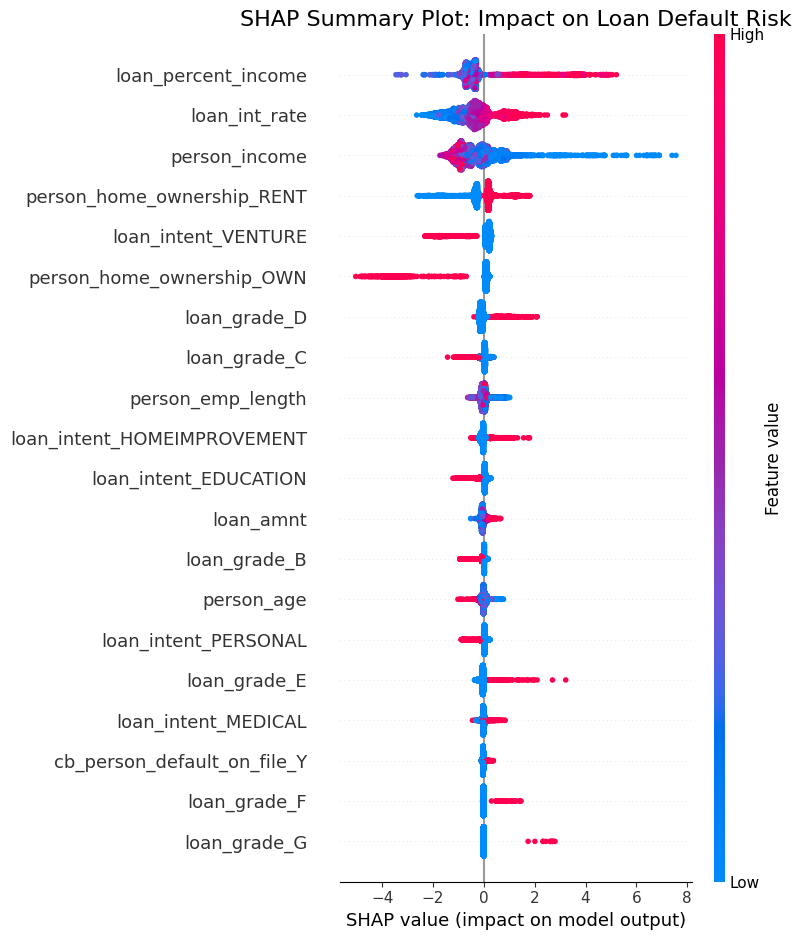

In [ ]:
import shap
import matplotlib.pyplot as plt

#  สร้าง Explainer จากโมเดล XGBoost ที่เทรนเสร็จแล้ว
explainer = shap.TreeExplainer(xgb_model)

#  คำนวณค่า SHAP Values จากชุดข้อมูลทดสอบ (X_test)
# เพื่อดูว่าในการทำนายข้อสอบแต่ละข้อ โมเดลใช้เหตุผลอะไร
shap_values = explainer.shap_values(X_test)

# วาดกราฟ Summary Plot (Beeswarm)
# เป็นกราฟที่แสดงทั้งความสำคัญของฟีเจอร์และทิศทางผลกระทบในกราฟเดียว
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: Impact on Loan Default Risk", fontsize=16)
shap.summary_plot(shap_values, X_test, plot_type="dot")